# Week 5: A New Perspective on Machine Learning

After spending the previous weeks building predictive models and working with labeled data, I started exploring a completely different area of machine learning.

This week marks the transition from supervised learning to unsupervised learning, where the focus shifts from making predictions to discovering hidden patterns within data.

In this notebook, I will document my progress, summarize the concepts I learn, and apply different techniques through practical Python examples as I continue exploring this new stage of the internship.

# Supervised vs. Unsupervised Learning

In this topic, I learned the difference between supervised learning and unsupervised learning.

In supervised learning, I worked with labeled data that contained both input features and a target variable.

In contrast, unsupervised learning does not use labels. Instead, it focuses on discovering hidden patterns and relationships within the data.

This topic helped me understand that the main goal of unsupervised learning is to explore the structure of the data rather than predict a known outcome.

In [1]:
import pandas as pd

employees = pd.DataFrame({
    "Experience": [1, 2, 3, 8, 9],
    "Salary": [2000, 2500, 3000, 8000, 8500],
    "Promoted": ["No", "No", "No", "Yes", "Yes"]
})

print(employees)

   Experience  Salary Promoted
0           1    2000       No
1           2    2500       No
2           3    3000       No
3           8    8000      Yes
4           9    8500      Yes


# What Clustering Does

In this section, I learned that clustering is a technique used to organize similar data points into groups.

The main idea is to place observations with similar characteristics in the same cluster while separating them from different observations.

I also learned that clustering algorithms can identify patterns automatically without requiring predefined labels.

In [2]:
import pandas as pd

products = pd.DataFrame({
    "Price": [10, 12, 15, 120, 125, 130],
    "Rating": [4.5, 4.7, 4.6, 3.1, 3.2, 3.0]
})

print(products)

   Price  Rating
0     10     4.5
1     12     4.7
2     15     4.6
3    120     3.1
4    125     3.2
5    130     3.0


# K-Means Clustering

In this topic, I learned how the K-Means algorithm creates clusters.

I learned that the algorithm starts by selecting a specific number of clusters and placing centroids.

After that, each data point is assigned to the nearest centroid, and the centroid locations are updated repeatedly until the clusters become stable.

Understanding this process helped me see how clustering algorithms organize data into meaningful groups.

In [3]:
from sklearn.cluster import KMeans
import pandas as pd

students = pd.DataFrame({
    "Study_Hours": [2, 3, 4, 8, 9, 10],
    "Exam_Score": [50, 55, 60, 90, 92, 95]
})

kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

students["Cluster"] = kmeans.fit_predict(students)

print(students)

print("\nCentroids:")

print(kmeans.cluster_centers_)

   Study_Hours  Exam_Score  Cluster
0            2          50        0
1            3          55        0
2            4          60        0
3            8          90        1
4            9          92        1
5           10          95        1

Centroids:
[[ 3.         55.        ]
 [ 9.         92.33333333]]


# The Elbow Method

In this section, I learned how to determine the optimal number of clusters.

The Elbow Method works by running the K-Means algorithm multiple times using different values of k and calculating the inertia for each model.

By plotting the results, I was able to identify the point where the improvement started to decrease and select the most appropriate number of clusters.

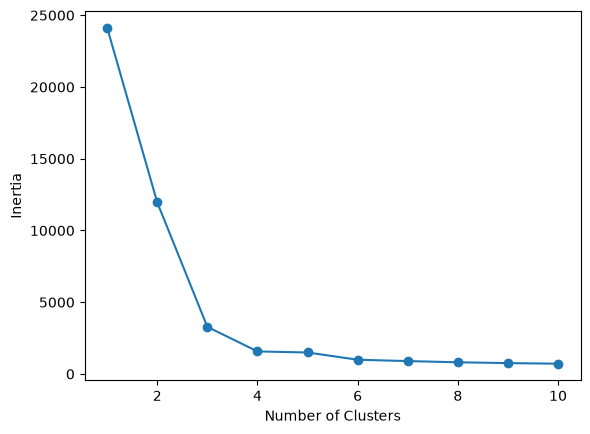

In [4]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, _ = make_blobs(
    n_samples=400,
    centers=5,
    cluster_std=1.2,
    random_state=42
)

inertia_values = []

for k in range(1, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X)

    inertia_values.append(model.inertia_)

plt.plot(range(1, 11), inertia_values, marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()

# Silhouette Score

In this topic, I learned how to evaluate clustering quality using the Silhouette Score.

This metric measures how well each observation fits within its own cluster compared to neighboring clusters.

I learned that higher values indicate better cluster separation and more reliable clustering results.

In [5]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

X, _ = make_blobs(
    n_samples=300,
    centers=4,
    random_state=42
)

model = KMeans(
    n_clusters=4,
    random_state=42
)

labels = model.fit_predict(X)

score = silhouette_score(X, labels)

print("Silhouette Score:", score)

Silhouette Score: 0.7915830011443039


# Scaling Before Clustering

In this section, I learned why feature scaling is important before applying clustering algorithms.

Since K-Means depends on distance calculations, features with larger values can have a stronger influence on the results.

Using StandardScaler ensures that all features contribute equally during the clustering process.

In [6]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

customers = pd.DataFrame({
    "Income": [2500, 5000, 10000, 15000],
    "Age": [20, 25, 35, 50]
})

scaler = StandardScaler()

scaled_data = scaler.fit_transform(customers)

print(scaled_data)

[[-1.1717002  -1.09108945]
 [-0.65094455 -0.65465367]
 [ 0.39056673  0.21821789]
 [ 1.43207802  1.52752523]]
